In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns     
 

In [3]:
# Read the online retail dataset
df = pd.read_csv('../data/Walmart.csv')
print("===Dataset information===")
print(f"Shape    : {df.shape}")
print(f"Columns  : {list(df.columns)}")
 
df.head(5)

===Dataset information===
Shape    : (3203, 12)
Columns  : ['Order ID', 'Order Date', 'Ship Date', 'Customer Name', 'Country', 'City', 'State', 'Category', 'Product Name', 'Sales', 'Quantity', 'Profit']


,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,13-06-2013,17-06-2013,Darrin Van Huff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,6.87
1,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7.0,14.17
2,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Art,Newell 322,7.28,4.0,1.97
3,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Phones,Mitel 5320 IP Phone VoIP phone,907.15,4.0,90.72
4,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Binders,DXL Angle-View Binders with Locking Rings by S...,18.50,3.0,5.78


In [4]:
#check data inconsistencies
print("===Data inconsistencies===") 
print(f"Missing values:\n{df.isnull().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
 


===Data inconsistencies===
Missing values:
Order ID         0
Order Date       0
Ship Date        0
Customer Name    0
Country          0
City             0
State            0
Category         0
Product Name     0
Sales            0
Quantity         0
Profit           0
dtype: int64
Duplicate rows: 0


In [5]:
# Missing values per column
print("=== Missing values ===")
print(df.isnull().sum())

 
 
 

=== Missing values ===
Order ID         0
Order Date       0
Ship Date        0
Customer Name    0
Country          0
City             0
State            0
Category         0
Product Name     0
Sales            0
Quantity         0
Profit           0
dtype: int64


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')

In [7]:
df.drop(columns=['Ship Date'], inplace=True)

In [8]:
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

In [9]:
#unit price column
df['Unit Price'] = df['Sales'] / df['Quantity']


In [10]:
df.head(5)


,Order ID,Order Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit,Month,Year,Unit Price
0,CA-2013-138688,2013-06-13,Darrin Van Huff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,6.87,6,2013,7.310000
1,CA-2011-115812,2011-06-09,Brosina Hoffman,United States,Los Angeles,California,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7.0,14.17,6,2011,6.980000
2,CA-2011-115812,2011-06-09,Brosina Hoffman,United States,Los Angeles,California,Art,Newell 322,7.28,4.0,1.97,6,2011,1.820000
3,CA-2011-115812,2011-06-09,Brosina Hoffman,United States,Los Angeles,California,Phones,Mitel 5320 IP Phone VoIP phone,907.15,4.0,90.72,6,2011,226.787500
4,CA-2011-115812,2011-06-09,Brosina Hoffman,United States,Los Angeles,California,Binders,DXL Angle-View Binders with Locking Rings by S...,18.50,3.0,5.78,6,2011,6.166667


In [11]:
df.describe()

,Order Date,Sales,Quantity,Profit,Month,Year,Unit Price
count,3203,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000
mean,2013-05-10 03:06:07.530440192,226.493266,3.828910,33.849138,8.025289,2012.729941,60.724518
min,2011-01-07 00:00:00,0.990000,1.000000,-3399.980000,1.000000,2011.000000,0.540000
25%,2012-05-22 00:00:00,19.440000,2.000000,3.850000,5.000000,2012.000000,6.335833
50%,2013-07-22 00:00:00,60.840000,3.000000,11.170000,9.000000,2013.000000,18.335000
75%,2014-05-23 00:00:00,215.810000,5.000000,33.000000,11.000000,2014.000000,63.965714
max,2014-12-31 00:00:00,13999.960000,14.000000,6719.980000,12.000000,2014.000000,3499.990000
std,NaN,524.876911,2.260947,174.109155,3.254793,1.138640,132.665086


In [12]:
#profit by product category
profit_by_category = df.groupby('Category')['Profit'].sum().reset_index()
print(profit_by_category)

       Category    Profit
0   Accessories  16484.62
1    Appliances   8261.29
2           Art   2374.15
3       Binders  16096.78
4     Bookcases  -1646.50
5        Chairs   4027.62
6       Copiers  19327.25
7     Envelopes   1908.71
8     Fasteners    275.19
9   Furnishings   7641.26
10       Labels   2303.07
11     Machines   -618.95
12        Paper  12119.10
13       Phones   9111.06
14      Storage   8645.49
15     Supplies    626.11
16       Tables   1482.54


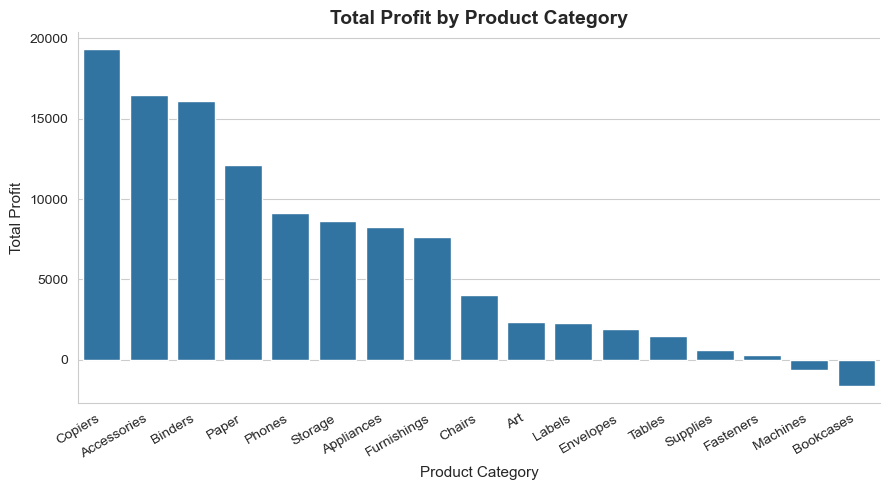

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort data (very important for readability)
profit_by_category = profit_by_category.sort_values(by='Profit', ascending=False)

plt.figure(figsize=(9, 5))

# Better style
sns.set_style("whitegrid")

ax = sns.barplot(
    data=profit_by_category,
    x='Category',
    y='Profit'
)

# Titles & labels
plt.title('Total Profit by Product Category', fontsize=14, weight='bold')
plt.xlabel('Product Category', fontsize=11)
plt.ylabel('Total Profit', fontsize=11)

# Rotate labels nicely
plt.xticks(rotation=30, ha='right')

 
# Remove top/right borders (clean look)
sns.despine()

plt.tight_layout()
plt.show()

C:\Users\eyram\AppData\Local\Temp\ipykernel_25088\2750767032.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='Profit', y='Product Name', palette='viridis')


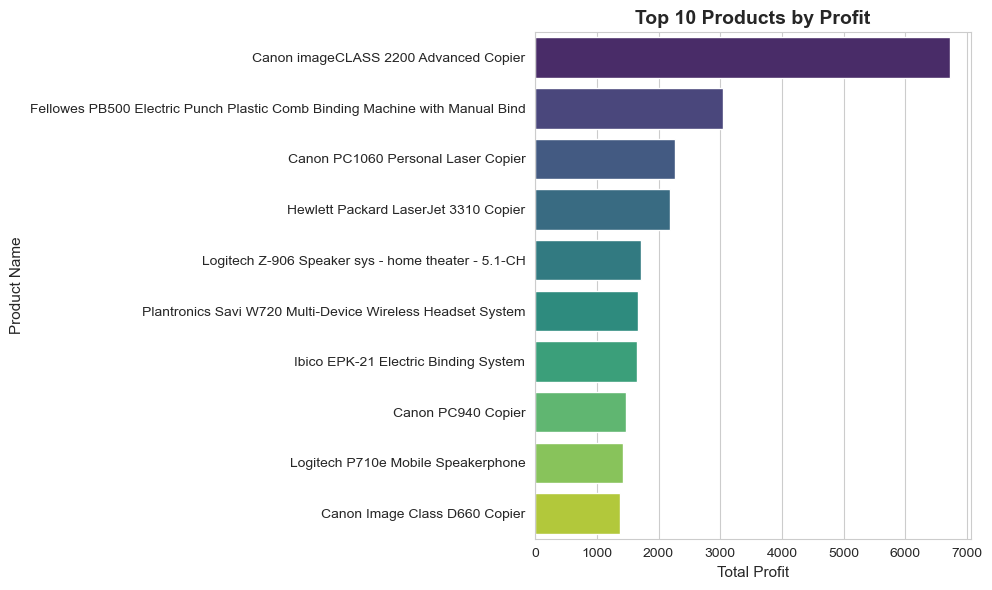

In [14]:
#top 10 product by profit plot
top_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x='Profit', y='Product Name', palette='viridis')
plt.title('Top 10 Products by Profit', fontsize=14, weight='bold')
plt.xlabel('Total Profit', fontsize=11)
plt.ylabel('Product Name', fontsize=11)
plt.tight_layout()
plt.show()

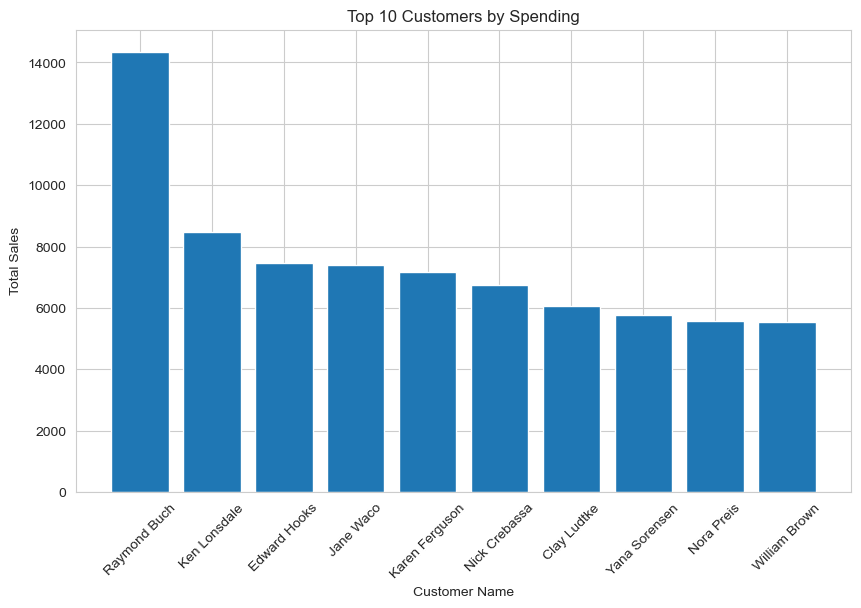

In [15]:
#Who are our top customers (by spending)
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(10, 6))
plt.bar(top_customers['Customer Name'], top_customers['Sales'])
plt.xlabel('Customer Name')
plt.ylabel('Total Sales')
plt.title('Top 10 Customers by Spending')
plt.xticks(rotation=45)
plt.show()

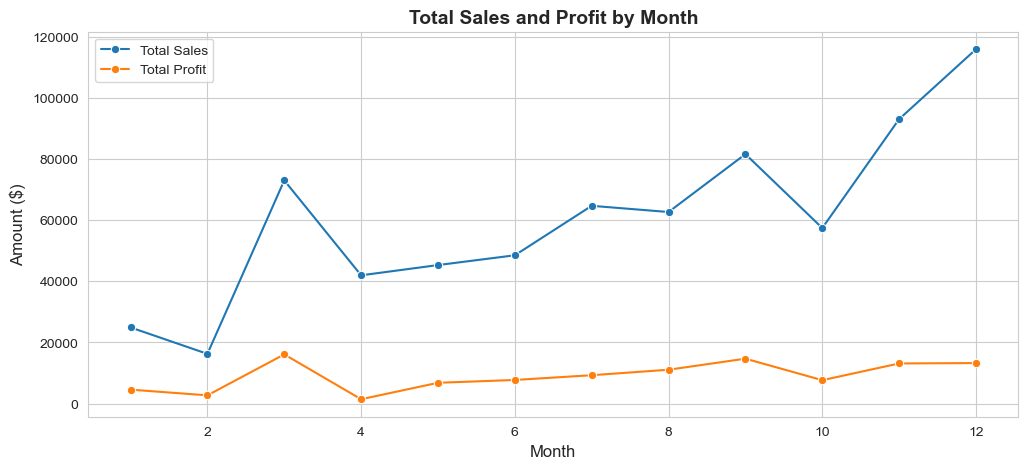

In [18]:
#total sales by month and total profit by month
sales_by_month = df.groupby('Month')['Sales'].sum().reset_index()
profit_by_month = df.groupby('Month')['Profit'].sum().reset_index()
plt.figure(figsize=(12, 5))
sns.lineplot(data=sales_by_month, x='Month', y='Sales', marker='o', label='Total Sales')
sns.lineplot(data=profit_by_month, x='Month', y='Profit', marker='o', label='Total Profit')
plt.title('Total Sales and Profit by Month', fontsize=14, weight='bold')    
plt.xlabel('Month', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.legend()
plt.show()

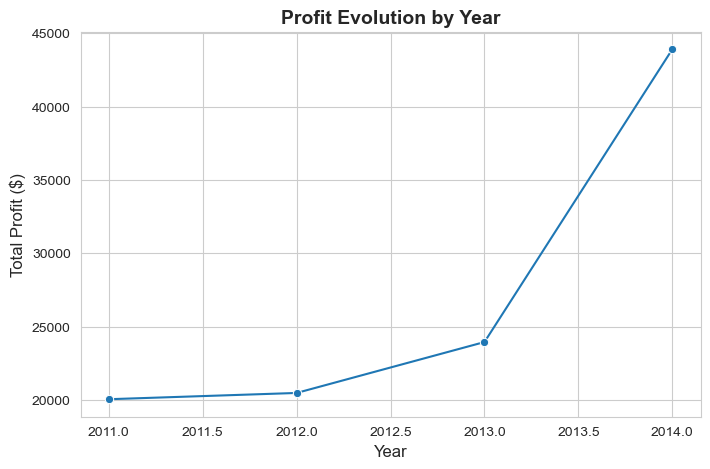

In [19]:
#profit evolution by year
profit_by_year = df.groupby('Year')['Profit'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.lineplot(data=profit_by_year, x='Year', y='Profit', marker='o')
plt.title('Profit Evolution by Year', fontsize=14, weight='bold')   
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Profit ($)', fontsize=12)
plt.show()

In [20]:
!pip install squarify

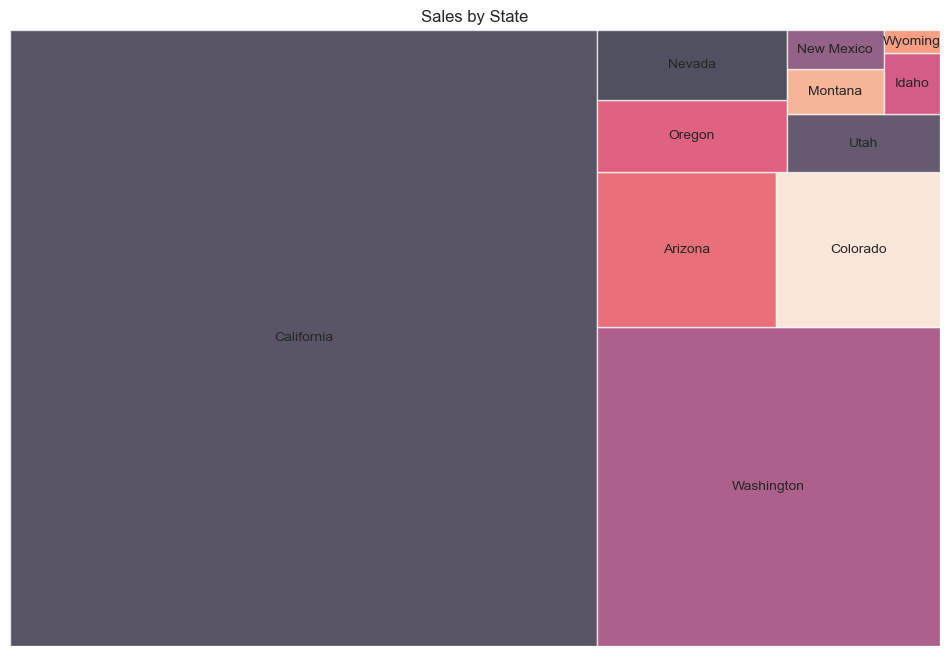

In [ ]:
#sale by state treemap
sales_by_state = df.groupby('State')['Sales'].sum().reset_index()
sales_by_state = sales_by_state.sort_values(by='Sales', ascending=False)
plt.figure(figsize=(12, 8))
plt.title('Sales by State')
plt.axis('off')
plt.show()


In [37]:
# statiscal summary
print(df.describe())
print("=== Profit by Category Summary ===")
print(profit_by_category.describe())





                          Order Date         Sales     Quantity       Profit  \
count                           3203   3203.000000  3203.000000  3203.000000   
mean   2013-05-10 03:06:07.530440192    226.493266     3.828910    33.849138   
min              2011-01-07 00:00:00      0.990000     1.000000 -3399.980000   
25%              2012-05-22 00:00:00     19.440000     2.000000     3.850000   
50%              2013-07-22 00:00:00     60.840000     3.000000    11.170000   
75%              2014-05-23 00:00:00    215.810000     5.000000    33.000000   
max              2014-12-31 00:00:00  13999.960000    14.000000  6719.980000   
std                              NaN    524.876911     2.260947   174.109155   

             Month         Year   Unit Price  
count  3203.000000  3203.000000  3203.000000  
mean      8.025289  2012.729941    60.724518  
min       1.000000  2011.000000     0.540000  
25%       5.000000  2012.000000     6.335833  
50%       9.000000  2013.000000    18.335000

In [40]:
print("===top 10 product by profit summary===")
print(top_products) 
print("===top 10 customers by spending summary===")
print(top_customers)

===top 10 product by profit summary===
                                        Product Name   Profit
0              Canon imageCLASS 2200 Advanced Copier  6719.98
1  Fellowes PB500 Electric Punch Plastic Comb Bin...  3050.38
2                 Canon PC1060 Personal Laser Copier  2267.97
3               Hewlett Packard LaserJet 3310 Copier  2183.96
4  Logitech Z-906 Speaker sys - home theater - 5....  1715.95
5  Plantronics Savi W720 Multi-Device Wireless He...  1670.92
6               Ibico EPK-21 Electric Binding System  1644.29
7                                 Canon PC940 Copier  1480.47
8                 Logitech P710e Mobile Speakerphone  1418.78
9                      Canon Image Class D660 Copier  1379.98
===top 10 customers by spending summary===
    Customer Name     Sales
0    Raymond Buch  14345.28
1    Ken Lonsdale   8472.39
2    Edward Hooks   7447.77
3       Jane Waco   7391.53
4  Karen Ferguson   7182.76
5   Nick Crebassa   6734.23
6     Clay Ludtke   6069.65
7   Yana Sor

In [16]:


# 1. Frequency per user
user_freq = df.groupby('Customer Name')['Order ID'].nunique().reset_index()
user_freq.columns = [' Customer Name', 'purchase_count']

# 2. Overall average frequency
avg_freq = df['Order ID'].nunique() / df['Customer Name'].nunique()

print(f"Average Purchase Frequency: {avg_freq:.2f}")
 

Average Purchase Frequency: 2.35


In [17]:
#total profiit

total_profit = df['Profit'].sum()
print(f"Total Profit: ${total_profit:.2f}")

Total Profit: $108418.79


===Customer Churn Analysis===
          Customer Name  Order Count  Churned
0         Aaron Bergman            1     True
1         Aaron Hawkins            3    False
2        Aaron Smayling            3    False
3       Adam Bellavance            3    False
4             Adam Hart            3    False
..                  ...          ...      ...
681        Xylona Preis            4    False
682       Yana Sorensen            4    False
683      Yoseph Carroll            2    False
684    Zuschuss Carroll            5    False
685  Zuschuss Donatelli            2    False

[686 rows x 3 columns]
